In [132]:
from leitor_csv import ler_csvs_inbe
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import xgboost as xgb


In [133]:
pasta = r'C:\Users\vitor\OneDrive\Documentos\Github\previsao_incendios\dados'
arquivos = os.listdir(pasta)
dfs = []

for arquivo in arquivos:
    if arquivo.startswith('focos_br') and arquivo.endswith('.csv'):
        caminho = os.path.join(pasta, arquivo)
            
            # Lê em pedaços de 100 mil linhas
        for chunk in pd.read_csv(caminho, sep=',', encoding='utf-8', chunksize=100000):
            dfs.append(chunk)

df = pd.concat(dfs, ignore_index=True)


In [134]:
df.head()

,latitude,longitude,data_pas,satelite,pais,estado,municipio,bioma,numero_dias_sem_chuva,precipitacao,risco_fogo,id_area_industrial,frp
0,-17.55708,-57.20554,2023-01-02 02:08:00,TERRA_M-M,Brasil,MATO GROSSO,POCONÉ,Pantanal,0.0,0.20,0.01,0,4.5
1,-17.55838,-57.21490,2023-01-02 02:08:00,TERRA_M-M,Brasil,MATO GROSSO,POCONÉ,Pantanal,0.0,0.15,0.01,0,14.5
2,-17.62477,-57.29403,2023-01-02 02:08:00,TERRA_M-M,Brasil,MATO GROSSO,POCONÉ,Pantanal,0.0,0.00,0.02,0,8.8
3,-17.62712,-57.17881,2023-01-02 02:08:00,TERRA_M-M,Brasil,MATO GROSSO,POCONÉ,Pantanal,0.0,0.10,0.02,0,6.7
4,-19.44473,-53.99815,2023-01-02 02:08:00,TERRA_M-M,Brasil,MATO GROSSO DO SUL,CAMAPUÃ,Cerrado,0.0,15.10,0.01,0,6.1


In [135]:
df.dtypes

latitude                 float64
longitude                float64
data_pas                     str
satelite                     str
pais                         str
estado                       str
municipio                    str
bioma                        str
numero_dias_sem_chuva    float64
precipitacao             float64
risco_fogo               float64
id_area_industrial         int64
frp                      float64
dtype: object

In [136]:
df.describe()

,latitude,longitude,numero_dias_sem_chuva,precipitacao,risco_fogo,id_area_industrial,frp
count,1.628756e+07,1.628756e+07,1.621654e+07,1.621654e+07,1.621654e+07,16287563.0,1.576894e+07
mean,-9.727313e+00,-5.189594e+01,1.723138e+01,6.286326e-01,-8.654785e+00,0.0,3.844735e+01
std,5.824589e+00,7.248283e+00,1.083397e+02,3.220243e+00,9.669894e+01,0.0,7.128829e+01
min,-3.373760e+01,-7.386338e+01,-9.990000e+02,0.000000e+00,-9.990000e+02,0.0,-3.800000e+00
25%,-1.308679e+01,-5.713660e+01,4.000000e+00,0.000000e+00,6.200000e-01,0.0,3.800000e+00
50%,-9.002310e+00,-5.128070e+01,1.100000e+01,0.000000e+00,1.000000e+00,0.0,1.000000e+01
75%,-6.059900e+00,-4.597600e+01,3.600000e+01,0.000000e+00,1.000000e+00,0.0,5.640000e+01
max,5.217610e+00,-3.479613e+01,1.200000e+02,2.529800e+02,1.000000e+00,0.0,1.231130e+04


In [137]:
df['data'] = pd.to_datetime(df['data_pas'], errors='coerce')
df['mes'] = df['data'].dt.month
df['ano'] = df['data'].dt.year
df['semana'] = df['data'].dt.isocalendar().week
df['dia'] = df['data'].dt.day

In [138]:
df['bioma'].unique()

<ArrowStringArray>
['Pantanal', 'Cerrado', 'Mata Atlântica', 'Caatinga', 'Amazônia', 'Pampa',
 nan]
Length: 7, dtype: str

In [139]:
df['id_area_industrial'] =df['id_area_industrial'].apply(lambda x: 1 if x > 0 else 0)
df['numero_dias_sem_chuva'] = df['numero_dias_sem_chuva'].apply(lambda x: np.nan if x < 0 else x)
df['risco_fogo'] = df['risco_fogo'].apply(lambda x: np.nan if x < 0 else x)

df['numero_dias_sem_chuva'] = df['numero_dias_sem_chuva'].fillna(df['numero_dias_sem_chuva'].median())
df['risco_fogo'] = df['risco_fogo'].fillna(df['risco_fogo'].median())

df = df.rename(columns={'id_area_industrial': 'area_industrial'})
df = df.drop(columns=['data_pas'])


In [140]:
df.head()

,latitude,longitude,satelite,pais,estado,municipio,bioma,numero_dias_sem_chuva,precipitacao,risco_fogo,area_industrial,frp,data,mes,ano,semana,dia
0,-17.55708,-57.20554,TERRA_M-M,Brasil,MATO GROSSO,POCONÉ,Pantanal,0.0,0.20,0.01,0,4.5,2023-01-02 02:08:00,1,2023,1,2
1,-17.55838,-57.21490,TERRA_M-M,Brasil,MATO GROSSO,POCONÉ,Pantanal,0.0,0.15,0.01,0,14.5,2023-01-02 02:08:00,1,2023,1,2
2,-17.62477,-57.29403,TERRA_M-M,Brasil,MATO GROSSO,POCONÉ,Pantanal,0.0,0.00,0.02,0,8.8,2023-01-02 02:08:00,1,2023,1,2
3,-17.62712,-57.17881,TERRA_M-M,Brasil,MATO GROSSO,POCONÉ,Pantanal,0.0,0.10,0.02,0,6.7,2023-01-02 02:08:00,1,2023,1,2
4,-19.44473,-53.99815,TERRA_M-M,Brasil,MATO GROSSO DO SUL,CAMAPUÃ,Cerrado,0.0,15.10,0.01,0,6.1,2023-01-02 02:08:00,1,2023,1,2


In [141]:
satelites = df['satelite'].unique()
biomas_maiores_focos = df['bioma'].value_counts()
meses_maiores_focos = df['mes'].value_counts()
estados_maiores_focos = df['estado'].value_counts()

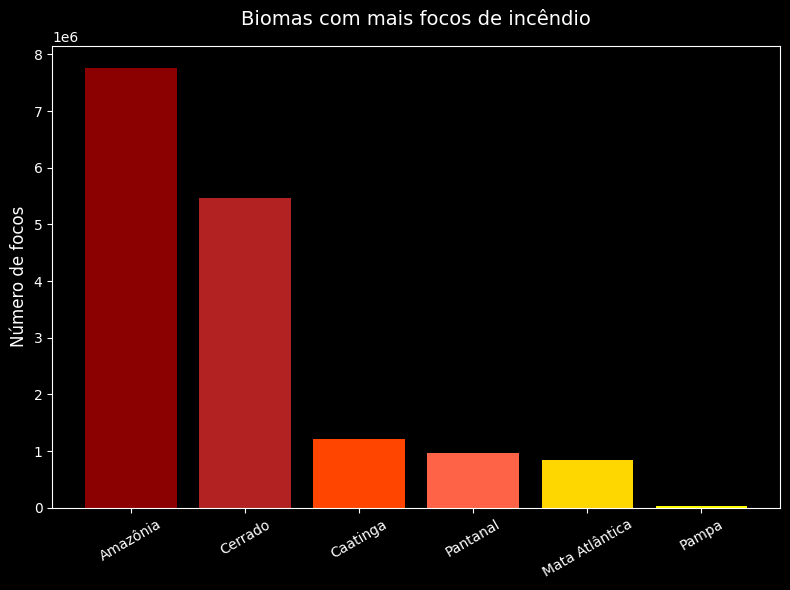

In [142]:

plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(8,6))

# Paleta neon personalizada
colors = [
    '#8B0000',  # vermelho escuro
    '#B22222',  # vermelho tijolo
    '#FF4500',  # laranja forte
    '#FF6347',  # vermelho tomate
    '#FFD700',  # amarelo ouro
    '#FFFF00'   # amarelo puro
]

ax.bar(
    biomas_maiores_focos.index,
    biomas_maiores_focos.values,
    color=colors
)

ax.set_title("Biomas com mais focos de incêndio", fontsize=14, color="white", pad=15)
ax.set_ylabel("Número de focos", fontsize=12, color="white")

# Tirar grid
ax.grid(False)

# Ajustar ticks
ax.tick_params(axis="x", colors="white", rotation=30)
ax.tick_params(axis="y", colors="white")

plt.tight_layout()
plt.show()


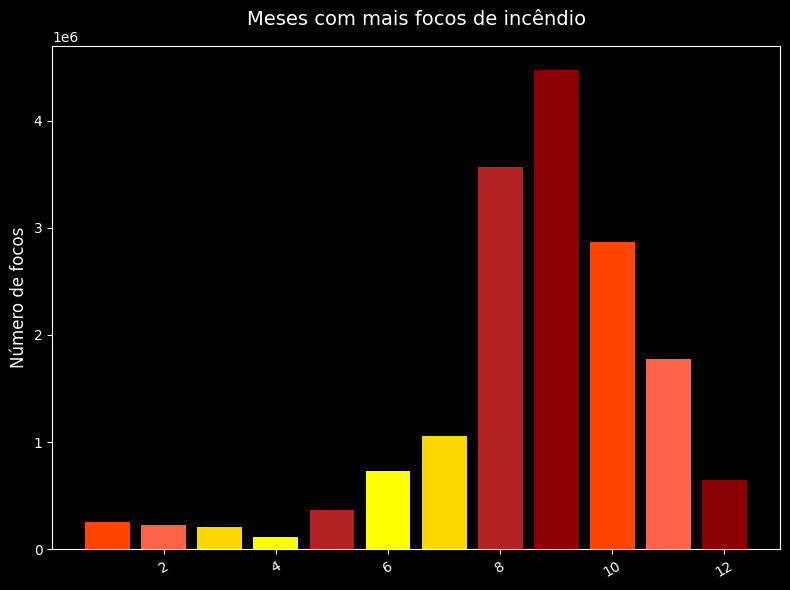

In [143]:

plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(8,6))

# Paleta neon personalizada
colors = [
    '#8B0000',  # vermelho escuro
    '#B22222',  # vermelho tijolo
    '#FF4500',  # laranja forte
    '#FF6347',  # vermelho tomate
    '#FFD700',  # amarelo ouro
    '#FFFF00'   # amarelo puro
]

ax.bar(
    meses_maiores_focos.index,
    meses_maiores_focos.values,
    color=colors
)

ax.set_title("Meses com mais focos de incêndio", fontsize=14, color="white", pad=15)
ax.set_ylabel("Número de focos", fontsize=12, color="white")

# Tirar grid
ax.grid(False)

# Ajustar ticks
ax.tick_params(axis="x", colors="white", rotation=30)
ax.tick_params(axis="y", colors="white")

plt.tight_layout()
plt.show()


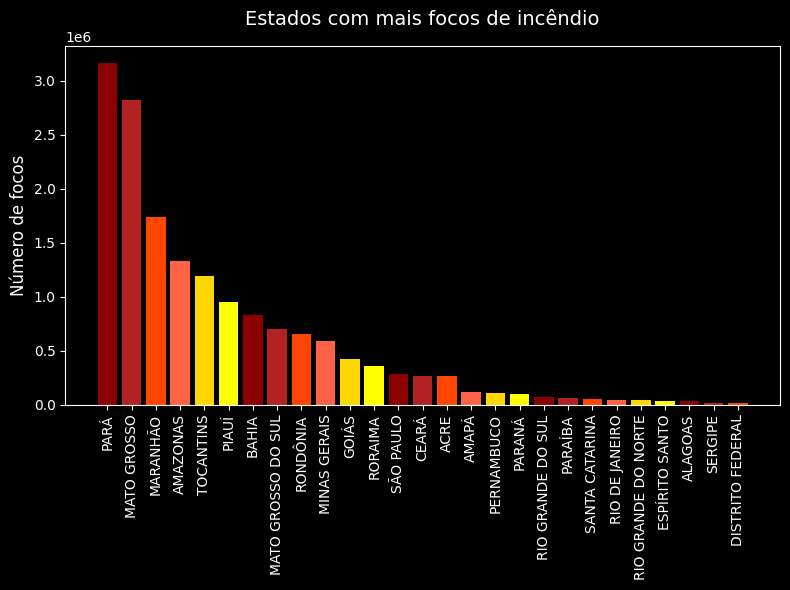

In [144]:

plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(8,6))

# Paleta neon personalizada
colors = [
    '#8B0000',  # vermelho escuro
    '#B22222',  # vermelho tijolo
    '#FF4500',  # laranja forte
    '#FF6347',  # vermelho tomate
    '#FFD700',  # amarelo ouro
    '#FFFF00'   # amarelo puro
]

ax.bar(
    estados_maiores_focos.index,
    estados_maiores_focos.values,
    color=colors
)

ax.set_title("Estados com mais focos de incêndio", fontsize=14, color="white", pad=15)
ax.set_ylabel("Número de focos", fontsize=12, color="white")

# Tirar grid
ax.grid(False)

# Ajustar ticks
ax.tick_params(axis="x", colors="white", rotation=90)
ax.tick_params(axis="y", colors="white")

plt.tight_layout()
plt.show()


In [145]:
df.head()

,latitude,longitude,satelite,pais,estado,municipio,bioma,numero_dias_sem_chuva,precipitacao,risco_fogo,area_industrial,frp,data,mes,ano,semana,dia
0,-17.55708,-57.20554,TERRA_M-M,Brasil,MATO GROSSO,POCONÉ,Pantanal,0.0,0.20,0.01,0,4.5,2023-01-02 02:08:00,1,2023,1,2
1,-17.55838,-57.21490,TERRA_M-M,Brasil,MATO GROSSO,POCONÉ,Pantanal,0.0,0.15,0.01,0,14.5,2023-01-02 02:08:00,1,2023,1,2
2,-17.62477,-57.29403,TERRA_M-M,Brasil,MATO GROSSO,POCONÉ,Pantanal,0.0,0.00,0.02,0,8.8,2023-01-02 02:08:00,1,2023,1,2
3,-17.62712,-57.17881,TERRA_M-M,Brasil,MATO GROSSO,POCONÉ,Pantanal,0.0,0.10,0.02,0,6.7,2023-01-02 02:08:00,1,2023,1,2
4,-19.44473,-53.99815,TERRA_M-M,Brasil,MATO GROSSO DO SUL,CAMAPUÃ,Cerrado,0.0,15.10,0.01,0,6.1,2023-01-02 02:08:00,1,2023,1,2


In [146]:
df_incendios = df.drop(columns= ['satelite','pais','data','latitude','longitude','area_industrial',])
df_incendios['incendio'] = 1

df_incendios = df_incendios.groupby(['semana','municipio','estado','ano','mes','dia']).agg(
    incendio_total=('incendio','sum'),
    risco_fogo_medio=('risco_fogo','mean'),
    precipitacao_total=('precipitacao','sum'),
    dias_sem_chuva_max=('numero_dias_sem_chuva','max'),
    bioma=('bioma',  pd.Series.mode) 
).reset_index()

df_incendios['teve_incendio'] = 1


In [147]:
df_incendios.head()

,semana,municipio,estado,ano,mes,dia,incendio_total,risco_fogo_medio,precipitacao_total,dias_sem_chuva_max,bioma,teve_incendio
0,1,ABAETETUBA,PARÁ,2023,1,6,3,0.000000,0.40,11.0,Amazônia,1
1,1,ABAETETUBA,PARÁ,2023,1,7,3,0.000000,20.01,11.0,Amazônia,1
2,1,ABAETETUBA,PARÁ,2023,1,8,3,0.006667,7.75,2.0,Amazônia,1
3,1,ABAIARA,CEARÁ,2023,1,4,2,0.465000,2.00,0.0,Caatinga,1
4,1,ABAIARA,CEARÁ,2023,1,5,2,0.560000,0.00,1.0,Caatinga,1


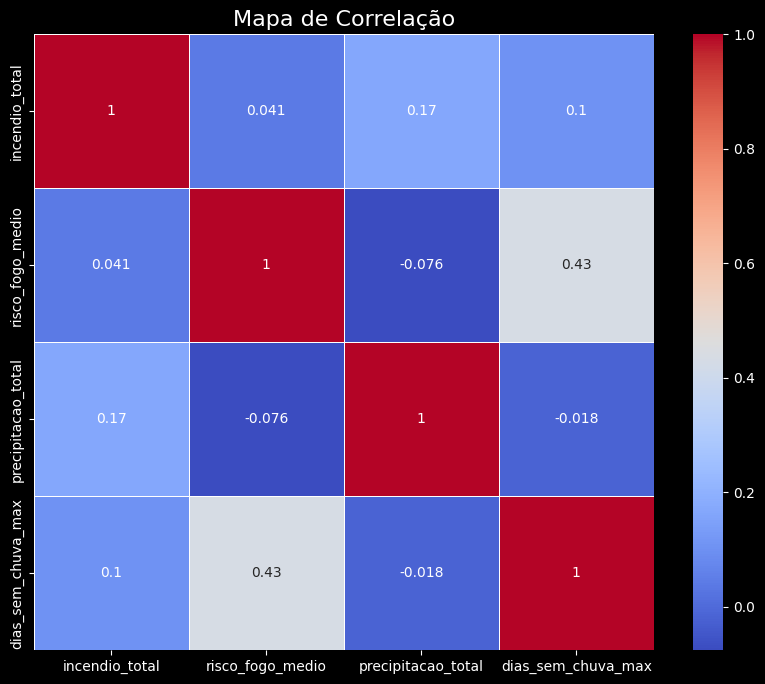

In [148]:
var_numericas = ['incendio_total', 'risco_fogo_medio', 'precipitacao_total', 'dias_sem_chuva_max']

corr = df_incendios[var_numericas].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Mapa de Correlação", fontsize=16)
plt.show()

In [149]:
semanas_sem_incendio = df['semana'].unique()

In [150]:
semanas_sem_incendio

<IntegerArray>
[ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,
 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 37, 36, 38,
 39, 40, 41, 42, 43, 52, 44, 45, 46, 47, 48, 49, 50, 51]
Length: 52, dtype: UInt32

In [151]:
df_incendios.head()

,semana,municipio,estado,ano,mes,dia,incendio_total,risco_fogo_medio,precipitacao_total,dias_sem_chuva_max,bioma,teve_incendio
0,1,ABAETETUBA,PARÁ,2023,1,6,3,0.000000,0.40,11.0,Amazônia,1
1,1,ABAETETUBA,PARÁ,2023,1,7,3,0.000000,20.01,11.0,Amazônia,1
2,1,ABAETETUBA,PARÁ,2023,1,8,3,0.006667,7.75,2.0,Amazônia,1
3,1,ABAIARA,CEARÁ,2023,1,4,2,0.465000,2.00,0.0,Caatinga,1
4,1,ABAIARA,CEARÁ,2023,1,5,2,0.560000,0.00,1.0,Caatinga,1


In [152]:

# Criar registros negativos sintéticos
negativos = []

sample = df_incendios.sample(frac=0.15, random_state=42)

for _, row in sample.iterrows():

    negativos.append({
        'semana': row['semana'],
        'municipio': row['municipio'],
        'estado': row['estado'],
        'ano': row['ano'],
        'mes': row['mes'],
        'dia': row['dia'],
        'incendio_total': 0,
        'risco_fogo_medio': np.random.uniform(0, np.quantile(df_incendios['risco_fogo_medio'], 0.2)),  # risco baixo
        'precipitacao_total': np.random.uniform(20, 100),  # chuva alta
        'dias_sem_chuva_max': np.random.randint(0, 3),  # poucos dias sem chuva
        'bioma': row['bioma'],
        'teve_incendio': 0
    })

df_negativos = pd.DataFrame(negativos)

# Concatenar positivos e negativos
df_final = pd.concat([df_incendios, df_negativos], ignore_index=True)


KeyboardInterrupt: 

In [ ]:
for col in ['municipio', 'estado', 'bioma']:
    le = LabelEncoder()
    df_final[col] = le.fit_transform(df_final[col])

df_final = df_final.drop(columns=['ano','dia'])

x = df_final.drop(columns=['teve_incendio'])
y = df_final['teve_incendio']

x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y,test_size=0.2, random_state=42)

xgb_clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    scale_pos_weight=1  
)

xgb_clf.fit(x_train, y_train)

y_pred_xgb = xgb_clf.predict(x_test)
print("XGBoost:\n", classification_report(y_test, y_pred_xgb))

,semana,municipio,estado,ano,mes,dia,incendio_total,risco_fogo_medio,precipitacao_total,dias_sem_chuva_max,bioma,teve_incendio
860970,4,CANGUÇU,RIO GRANDE DO SUL,2025,1,22,0,0.180569,26.879700,2.0,Pampa,0
860971,31,PORTO MURTINHO,MATO GROSSO DO SUL,2025,7,30,0,0.172885,72.685975,1.0,Cerrado,0
860972,36,COLINA,SÃO PAULO,2023,9,8,0,0.059797,66.304073,1.0,Cerrado,0
860973,38,SÃO SEBASTIÃO DO UATUMÃ,AMAZONAS,2024,9,17,0,0.084755,66.080007,0.0,Amazônia,0
860974,10,NOVA MARINGÁ,MATO GROSSO,2025,3,7,0,0.169850,20.665596,0.0,Amazônia,0
